# Task 3 — Cross-country comparison

This notebook loads the **cleaned** outputs from Task 2:

- `data/<country>_clean.csv` for Ethiopia, Kenya, Sudan, Tanzania, Nigeria

It then compares temperature and precipitation patterns, computes extreme heat and dry-day metrics, runs a cross-country statistical test (ANOVA/Kruskal), and produces a vulnerability ranking for COP32-style narrative.


In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.constants import COUNTRIES
from src.io import load_cleaned_country_csv
from src.analysis import (
    summary_stats_table,
    anova_or_kruskal_t2m,
    vulnerability_ranking,
)

sns.set_theme(style="whitegrid")


## Load and concatenate cleaned datasets

In [2]:
dfs = []
for c in COUNTRIES:
    d = load_cleaned_country_csv(c)
    d["Country"] = c
    d["DATE"] = pd.to_datetime(d["DATE"], errors="coerce")
    d["Month"] = d["DATE"].dt.month
    dfs.append(d)

df_all = pd.concat(dfs, ignore_index=True)
df_all.head()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,ethiopia,2015-01-05,1


## Monthly average T2M (all countries)

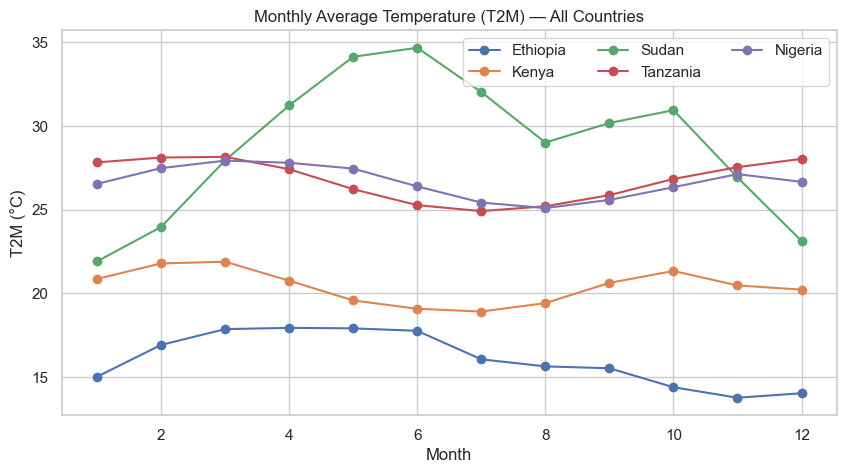

In [3]:
monthly = (
    df_all.groupby(["Country", "Month"], as_index=False)["T2M"]
    .mean()
    .sort_values(["Country", "Month"])
)

plt.figure(figsize=(10, 5))
for c in COUNTRIES:
    g = monthly[monthly["Country"] == c]
    plt.plot(g["Month"], g["T2M"], marker="o", label=c.title())
plt.title("Monthly Average Temperature (T2M) — All Countries")
plt.xlabel("Month")
plt.ylabel("T2M (°C)")
plt.legend(ncol=3)
plt.show()


## Side-by-side boxplots of precipitation (PRECTOTCORR)

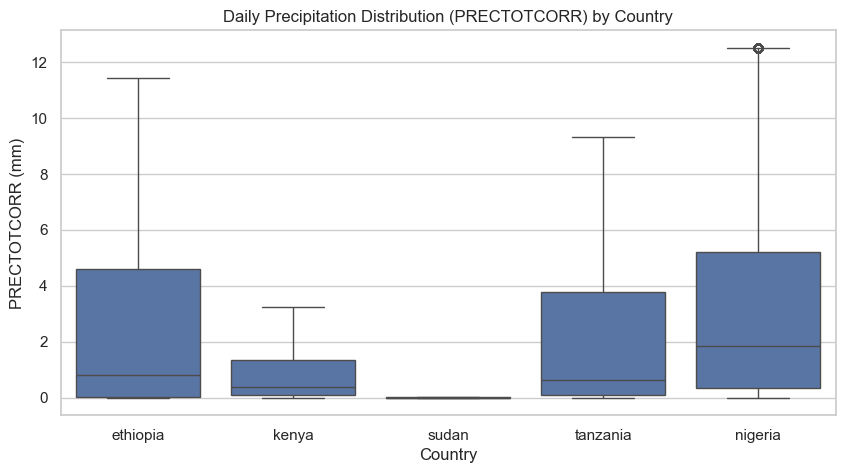

In [4]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_all, x="Country", y="PRECTOTCORR")
plt.title("Daily Precipitation Distribution (PRECTOTCORR) by Country")
plt.xlabel("Country")
plt.ylabel("PRECTOTCORR (mm)")
plt.show()


## Summary tables (T2M and PRECTOTCORR)

In [5]:
summary_t2m = summary_stats_table(df_all, "T2M")
summary_prect = summary_stats_table(df_all, "PRECTOTCORR")

display(summary_t2m)
display(summary_prect)


,Country,mean,median,std
0,ethiopia,16.070465,16.04,1.891031
1,kenya,20.426826,20.36,1.434426
2,nigeria,26.658532,26.82,1.117169
3,sudan,28.760005,29.16,4.678255
4,tanzania,26.802422,26.99,1.325388


,Country,mean,median,std
0,ethiopia,2.877663,0.82,3.851544
1,kenya,0.919747,0.38,1.108155
2,nigeria,3.432631,1.84,3.910056
3,sudan,0.006358,0.00,0.010634
4,tanzania,2.441828,0.64,3.251212


## Extreme heat days (T2M_MAX > 35°C) and dry days (PRECTOTCORR < 1mm)

In [6]:
df_all["Year"] = df_all["DATE"].dt.year

heat = (
    df_all.groupby(["Country", "Year"], as_index=False)
    .agg(ExtremeHeatDays=("T2M_MAX", lambda s: (s > 35).sum()))
)
dry = (
    df_all.groupby(["Country", "Year"], as_index=False)
    .agg(DryDays=("PRECTOTCORR", lambda s: (s < 1).sum()))
)

display(heat.head())
display(dry.head())


,Country,Year,ExtremeHeatDays
0,ethiopia,2015,0
1,ethiopia,2016,0
2,ethiopia,2017,0
3,ethiopia,2018,0
4,ethiopia,2019,0


,Country,Year,DryDays
0,ethiopia,2015,215
1,ethiopia,2016,176
2,ethiopia,2017,190
3,ethiopia,2018,194
4,ethiopia,2019,186


### Plot extreme heat days

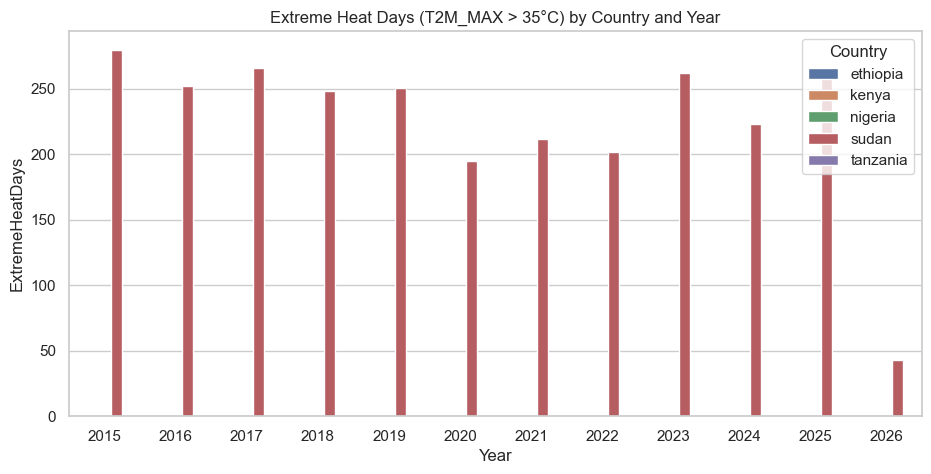

In [7]:
plt.figure(figsize=(11, 5))
sns.barplot(data=heat, x="Year", y="ExtremeHeatDays", hue="Country")
plt.title("Extreme Heat Days (T2M_MAX > 35°C) by Country and Year")
plt.show()


### Plot dry days

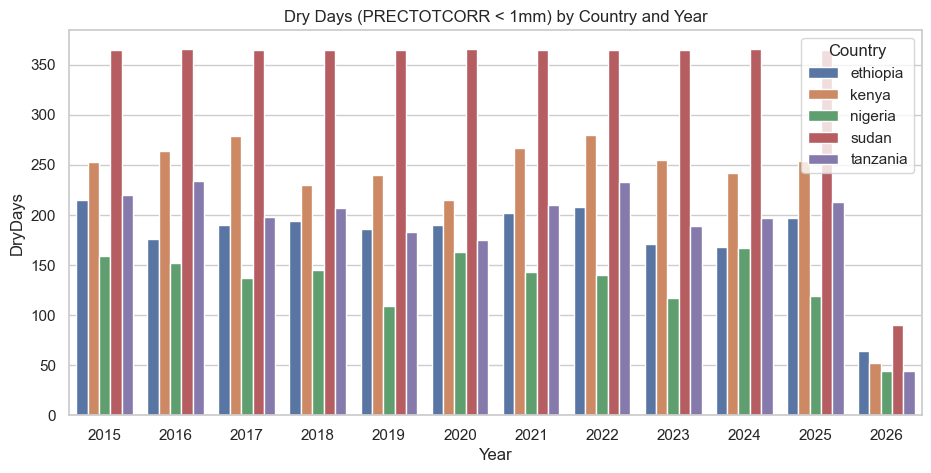

In [8]:
plt.figure(figsize=(11, 5))
sns.barplot(data=dry, x="Year", y="DryDays", hue="Country")
plt.title("Dry Days (PRECTOTCORR < 1mm) by Country and Year")
plt.show()


## Cross-country statistical test on T2M

In [9]:
test_name, p_value = anova_or_kruskal_t2m(df_all.dropna(subset=["T2M"]))
test_name, p_value


('kruskal', 0.0)

Interpretation:

- A small p-value (e.g., < 0.05) suggests temperature distributions differ across countries.
- We use **Kruskal–Wallis** if normality is questionable; otherwise **ANOVA**.


## Vulnerability ranking (heuristic composite)

In [10]:
rank_tbl = vulnerability_ranking(df_all)
rank_tbl


,rank,Country,vulnerability_score,warming_slope,precip_cv,ExtremeHeatDays,DryDays
0,1,sudan,4.000000,0.323716,1.672530,224.5,342.333333
1,2,tanzania,0.845681,-0.080424,1.331466,0.0,191.916667
2,3,kenya,0.705549,-0.137685,1.204848,0.0,235.916667
3,4,ethiopia,0.598919,-0.183556,1.338428,0.0,180.083333
4,5,nigeria,0.290193,-0.036349,1.139084,0.0,132.916667


## COP32-oriented takeaways (fill from results)

- Which country is warming fastest: identify the top `warming_slope` in the ranking table.
- Which country has the most unstable precipitation: highest `precip_cv`.
- What extreme heat and drought reveal: compare `ExtremeHeatDays` and `DryDays`.
- How Ethiopia compares to neighbors: contrast Ethiopia vs Kenya/Sudan/Tanzania.
- Priority climate finance: pick highest composite vulnerability with a short justification.
